# United States — Full Piotroski F-Score Study

The proposal's complete loop on **real data**: point-in-time universe →
high-B/M value subset → 9-signal F-Score → fixed-basket selection (F-Score vs
value / market-cap / liquidity-matched / random Monte-Carlo) → EW / GMV /
sector-capped GMV on RMT-cleaned covariances, plus a dollar-neutral
long-short book (long top-k scores, short bottom-k) where shorting is
available → annual-rebalance backtest →
placement in the random distribution → investable benchmarks → Fama-French
three-factor regression.

**Data & scope.** SEC EDGAR XBRL fundamentals (FY2009 onward — XBRL was mandated 2009-2011, which is why the proposal's 2000 start is not reachable from free filings) with **true 10-K filing dates** as `report_date`, so a 1-month buffer replaces the blanket 5-month lag. Universe membership is the S&P 500 list **as of each formation date** (historical constituents dataset), removing index-inclusion look-ahead; names whose price history has vanished from Yahoo (many delistings) still drop out — the residual survivorship is documented in the README. Formations run **July 2012 .. July 2024** — thirteen chained holding years, each a full twelve months. July 2024 is the last formation whose complete year finishes inside the sample; taking July 2025 as well would mix a half-year window in with the complete ones. Covariances are estimated on 36 months of daily returns ending the day before formation.

Run `python scripts/fetch_us_edgar.py`
once before this notebook (builds the git-ignored cache under `data/`).

In [1]:
import sys, pathlib
ROOT = pathlib.Path.cwd().parent
sys.path.insert(0, str(ROOT / "src"))

import numpy as np, pandas as pd, matplotlib.pyplot as plt
from fscore.plotting import setup_plots, save_fig
from fscore.data.yahoo import load_cached
from fscore.pipeline import run_study
from fscore.evaluation import (metrics, benchmark_returns, fetch_ff_factors,
                               factor_regression, to_usd)

setup_plots()      # study-wide figure defaults; every saved chart is 300 dpi
RESULTS_FIG = ROOT / "results" / "figures"
MARKET = "us"
YEARS = list(range(2012, 2025))
LAG_MONTHS = 1  # report_date = true 10-K filing date
END_CAP = None   # every holding year is complete; nothing is truncated
fund, prices, sectors, bench = load_cached(MARKET, ROOT / "data")
from fscore.data.edgar import load_membership
membership = load_membership(ROOT / "data")
print(f"fundamentals: {fund.ticker.nunique()} tickers, "
      f"FY{fund.fiscal_year.min()}–FY{fund.fiscal_year.max()}")
print(f"prices: {prices.ticker.nunique()} tickers, "
      f"{prices.date.min():%Y-%m-%d} → {prices.date.max():%Y-%m-%d}")
fund.groupby("fiscal_year").size().rename("statements")

fundamentals: 586 tickers, FY2006–FY2026


prices: 616 tickers, 2002-01-02 → 2026-08-07


fiscal_year
2006      1
2007      5
2008    260
2009    429
2010    477
2011    495
2012    503
2013    517
2014    526
2015    532
2016    537
2017    544
2018    556
2019    564
2020    570
2021    574
2022    579
2023    584
2024    586
2025    585
2026     19
Name: statements, dtype: int64

### 1. Run the multi-year study

Per formation year: universe = top-150 names by median dollar volume with
continuous listing and complete, published statements; value subset = top 40%
by B/M (~60 names); baskets of 30; 1,000 random baskets under EW (300 pushed
through the GMV / sector-GMV pipeline).

**Data discarded before any test.** A firm-year is scored
only when all nine signals are computable from the fiscal T-1 and T-2
statements; partial scores are dropped rather than summed over whatever is
available (an incomplete score is not a low score). The per-formation count
is `dropped_incomplete_signals` in the diagnostics below.

In [2]:
study = run_study(MARKET, fund, prices, sectors, YEARS,
                  n_mc=1000, n_mc_opt=300, lag_months=LAG_MONTHS,
                  membership=membership, end_cap=END_CAP, seed=42,
                  detone=False)   # RMT denoise only; see section 4b
diag = pd.DataFrame([{"year": yr.year, **yr.diagnostics} for yr in study.yearly])
diag.set_index("year")

,universe,value_set,scored,dropped_incomplete_signals,tie_break_slots,cov_est_days,delisted_in_holding_year,k,fscore_mean,fscore_basket_min
year,,,,,,,,,,
2012,150,60,60,197,17,756,0,30,5.733333,6
2013,150,60,60,209,18,753,0,30,5.433333,6
2014,150,60,60,218,11,752,0,30,5.666667,6
2015,150,60,59,220,13,753,0,30,5.694915,6
2016,150,60,60,224,10,756,0,30,4.966667,5
2017,150,60,59,188,18,756,0,30,5.372881,6
2018,150,60,60,192,16,755,0,30,5.616667,6
2019,150,60,52,231,13,752,0,30,6.134615,6
2020,150,60,58,224,15,754,0,30,5.517241,6


### 2. F-Score distribution within the value universe, per formation

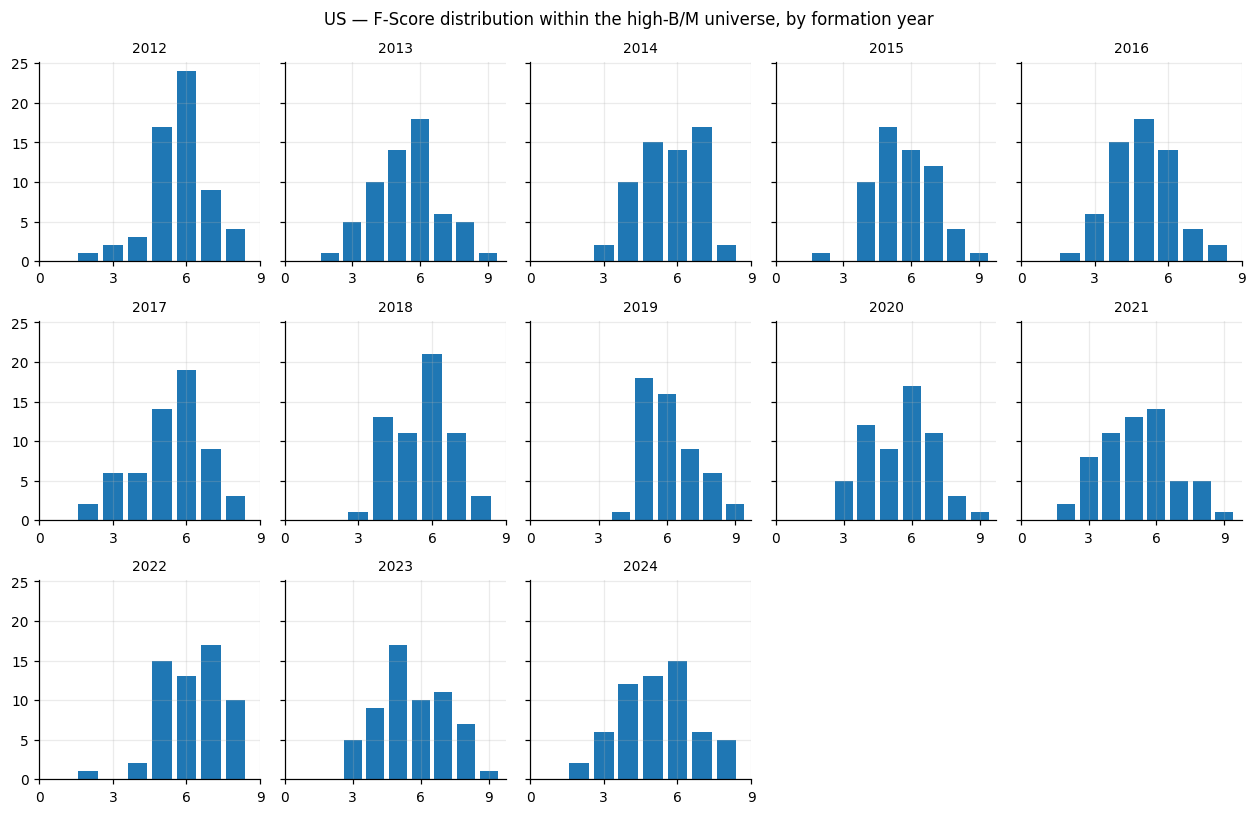

,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
count,60.00,60.00,60.00,59.00,60.00,59.00,60.00,52.00,58.00,59.00,58.00,60.00,59.00
mean,5.73,5.43,5.67,5.69,4.97,5.37,5.62,6.13,5.52,5.17,6.24,5.63,5.20
std,1.19,1.49,1.24,1.34,1.28,1.45,1.21,1.19,1.45,1.63,1.27,1.53,1.53
min,2.00,2.00,3.00,2.00,2.00,2.00,3.00,4.00,3.00,2.00,2.00,3.00,2.00
25%,5.00,4.00,5.00,5.00,4.00,5.00,5.00,5.00,4.00,4.00,5.00,5.00,4.00
50%,6.00,5.50,6.00,6.00,5.00,6.00,6.00,6.00,6.00,5.00,6.00,5.00,5.00
75%,6.00,6.00,7.00,7.00,6.00,6.00,6.00,7.00,6.75,6.00,7.00,7.00,6.00
max,8.00,9.00,8.00,9.00,8.00,8.00,8.00,9.00,9.00,9.00,8.00,9.00,8.00


In [3]:
ncol = min(5, len(YEARS))
nrow = -(-len(YEARS) // ncol)
fig, axes = plt.subplots(nrow, ncol, figsize=(2.3 * ncol, 2.5 * nrow),
                         sharey=True, squeeze=False)
for ax, yr in zip(axes.flat, study.yearly):
    counts = yr.scored.fscore.value_counts().sort_index()
    ax.bar(counts.index, counts.values)
    ax.set_title(f"{yr.year}", fontsize=9); ax.set_xticks(range(0, 10, 3))
for ax in axes.flat[len(study.yearly):]:
    ax.axis("off")
fig.suptitle(f"{MARKET.upper()} — F-Score distribution within the high-B/M universe, by formation year")
plt.tight_layout(); save_fig(f"{MARKET}_fscore_distribution", directory=RESULTS_FIG); plt.show()

pd.DataFrame({yr.year: yr.scored.fscore.describe() for yr in study.yearly}).round(2)

### 3. Chained track record vs investable benchmarks

Both benchmarks are USD, like the portfolios.

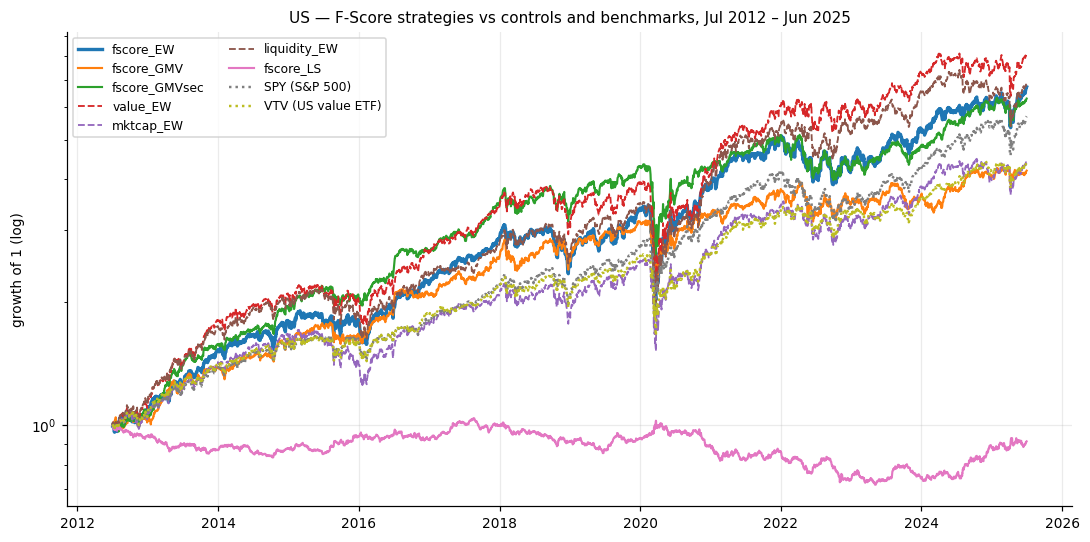

In [4]:
BENCH = {"SPY (S&P 500)": "SPY",
         "VTV (US value ETF)": "VTV"}
start, end = study.daily.index.min(), study.daily.index.max()
bench_rets = {name: benchmark_returns(bench, tk, start, end)
              for name, tk in BENCH.items()}

nav = (1 + study.daily.fillna(0)).cumprod()
fig, ax = plt.subplots(figsize=(10, 5))
# solid for the F-Score variants, dashed for the controls; a strategy not
# named here still plots, so adding one never breaks the figure
styles = {"fscore_EW": ("-", 2.2), "fscore_GMV": ("-", 1.4), "fscore_GMVsec": ("-", 1.4),
          "fscore_LS": ("-", 1.4),
          "value_EW": ("--", 1.2), "mktcap_EW": ("--", 1.2), "liquidity_EW": ("--", 1.2)}
for s in study.daily.columns:
    ls, lw = styles.get(s, ("-" if s.startswith("fscore") else "-.", 1.2))
    ax.plot(nav.index, nav[s], ls, lw=lw, label=s)
for name, r in bench_rets.items():
    ax.plot((1 + r).cumprod(), ":", lw=1.6, label=name)
ax.set_ylabel("growth of 1 (log)"); ax.set_yscale("log")
ax.set_title(f"{MARKET.upper()} — F-Score strategies vs controls and benchmarks, "
             f"{start:%b %Y} – {end:%b %Y}")
ax.legend(fontsize=8, ncol=2); plt.tight_layout()
save_fig(f"{MARKET}_nav_vs_benchmarks", directory=RESULTS_FIG); plt.show()

In [5]:
tbl = study.summary()      # gross first; costs follow separately
for name, r in bench_rets.items():
    tbl.loc[name] = metrics(r)   # benchmarks are buy-and-hold: no turnover
tbl[["ann_return", "ann_vol", "sharpe", "max_drawdown",
     "nominal_k", "effective_n"]].round(3)

,ann_return,ann_vol,sharpe,max_drawdown,nominal_k,effective_n
fscore_EW,0.159,0.202,0.786,-0.415,30.0,30.000
fscore_GMV,0.117,0.160,0.735,-0.320,30.0,5.644
fscore_GMVsec,0.153,0.174,0.880,-0.413,30.0,8.825
value_EW,0.176,0.213,0.825,-0.470,30.0,30.000
mktcap_EW,0.122,0.187,0.649,-0.403,30.0,30.000
liquidity_EW,0.160,0.207,0.776,-0.468,30.0,30.000
fscore_LS,-0.007,0.083,-0.084,-0.313,60.0,58.659
SPY (S&P 500),0.144,0.170,0.847,-0.337,NaN,NaN
VTV (US value ETF),0.121,0.160,0.756,-0.368,NaN,NaN


`nominal_k` is the basket size, `effective_n` is 1/Σw² —
an optimised or sector-capped book concentrates, so the two are not the same
number of holdings. Turnover and the net-of-cost sensitivity follow below.

In [6]:
tbl[["turnover", "cost_drag",
     "net_ann_return", "net_sharpe"]].round(4)

,turnover,cost_drag,net_ann_return,net_sharpe
fscore_EW,0.5667,0.0023,0.1568,0.7749
fscore_GMV,0.6076,0.0024,0.1150,0.7202
fscore_GMVsec,0.6588,0.0026,0.1505,0.8649
value_EW,0.2722,0.0011,0.1748,0.8194
mktcap_EW,0.2889,0.0012,0.1204,0.6430
liquidity_EW,0.6333,0.0025,0.1579,0.7639
fscore_LS,1.2074,0.0148,-0.0218,-0.2633
SPY (S&P 500),NaN,NaN,NaN,NaN
VTV (US value ETF),NaN,NaN,NaN,NaN


### 4. Statistical control — placement in the Monte-Carlo random distribution

Same universe, same basket size, same construction pipeline; the only
difference is *which* 30 names. Percentile = share of random baskets the
F-Score portfolio beats; the p-value is one-sided and judged at the study's
single significance level, **5%** (`significant` column). No 1% or 10% tier
is used, so p = 0.06 counts as not significant.

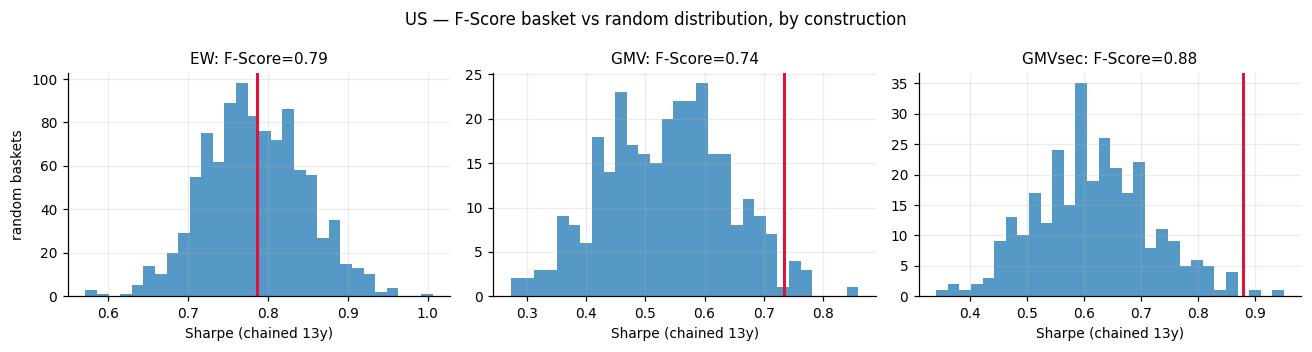

fscore random_mean random_std percentile  \
fscore_EW     ann_return    0.159023    0.159841   0.012159      0.494   
              sharpe        0.786068    0.784088   0.063046      0.527   
              max_drawdown -0.414904   -0.441076   0.024654      0.847   
fscore_GMV    ann_return     0.11744    0.090629   0.017034       0.94   
              sharpe        0.735418    0.535584    0.10489       0.97   
              max_drawdown -0.319797   -0.394138   0.038773   0.953333   
fscore_GMVsec ann_return    0.153112    0.107947   0.017011   0.996667   
              sharpe        0.880034     0.61663   0.102665   0.993333   
              max_drawdown -0.413223   -0.411123    0.03514   0.456667   

                             p_value significant n_draws  
fscore_EW     ann_return       0.506       False    1000  
              sharpe           0.473       False    1000  
              max_drawdown     0.153       False    1000  
fscore_GMV    ann_return        0.06       False     300  
              sharpe            0.03        True     300  
              max_drawdown  0.046667        True     300  
fscore_GMVsec ann_return    0.003333        True     300  
              sharpe        0.006667        True     300  
              max_drawdown  0.543333       False     300

In [7]:
pairs = [("EW", "fscore_EW"), ("GMV", "fscore_GMV"), ("GMVsec", "fscore_GMVsec")]
fig, axes = plt.subplots(1, 3, figsize=(12, 3.2), sharey=False)
for ax, (how, strat) in zip(axes, pairs):
    sharpes = study.mc_summary(how)["sharpe"].dropna()
    fs = metrics(study.daily[strat].dropna())["sharpe"]
    ax.hist(sharpes, bins=30, alpha=0.75)
    ax.axvline(fs, color="crimson", lw=2)
    ax.set_title(f"{how}: F-Score={fs:.2f}", fontsize=10)
    ax.set_xlabel(f"Sharpe (chained {len(YEARS)}y)")
axes[0].set_ylabel("random baskets")
fig.suptitle(f"{MARKET.upper()} — F-Score basket vs random distribution, by construction")
plt.tight_layout(); save_fig(f"{MARKET}_mc_placement", directory=RESULTS_FIG); plt.show()

placements = pd.concat({strat: study.placement(strat, how) for how, strat in pairs})
placements.round(3)

### 4b. RMT covariance: denoise only vs denoise + detone

The covariance fed to the minimum-variance solve is RMT-denoised
(Marchenko–Pastur noise band flattened). **Detoning** — additionally removing
the dominant market eigenmode — is off by default because it leaves the
matrix singular, so inverting it optimises residual risk only. This section
runs the detoned variant side by side to quantify what that choice costs.

In [8]:
study_dt = run_study(MARKET, fund, prices, sectors, YEARS,
                     n_mc=1000, n_mc_opt=300, lag_months=LAG_MONTHS,
                     membership=membership, end_cap=END_CAP, seed=42,
                     detone=True)

def _diag(st, label):
    yr = st.yearly[0]
    w = yr.weights["fscore_GMV"]
    cov = clean_rmt(holding_returns(prices, list(w.index),
                                    formation_date(yr.year) - pd.DateOffset(years=1),
                                    formation_date(yr.year) - pd.Timedelta(days=1))[list(w.index)],
                    detone=(label == "denoise+detone"))
    ev = np.linalg.eigvalsh(cov)
    m_ = metrics(st.daily["fscore_GMV"].dropna())
    return {"construction": label,
            "min eigenvalue": ev.min(),
            "condition number": ev.max() / max(ev.min(), 1e-300),
            "max weight": w.max(),
            "effective N": 1 / (w ** 2).sum(),
            "predicted ann vol": np.sqrt(w.values @ cov @ w.values * 252),
            "realised ann vol": m_["ann_vol"],
            "ann return": m_["ann_return"],
            "sharpe": m_["sharpe"]}

from fscore.construction import clean_rmt
from fscore.pipeline import holding_returns, formation_date
cmp = pd.DataFrame([_diag(study, "denoise only"), _diag(study_dt, "denoise+detone")])
cmp.set_index("construction").T

construction,denoise only,denoise+detone
min eigenvalue,0.000048,-5.207458e-19
condition number,221.732813,1.329434e+297
max weight,0.634130,5.155642e-02
effective N,2.267679,2.771936e+01
predicted ann vol,0.159305,7.635666e-03
realised ann vol,0.159692,2.012406e-01
ann return,0.117440,1.666012e-01
sharpe,0.735418,8.278708e-01


In [9]:
rows = {}
for label, st in [("denoise only", study), ("denoise+detone", study_dt)]:
    for strat in ["fscore_GMV", "fscore_GMVsec"]:
        pl = st.placement(strat, "GMV" if strat == "fscore_GMV" else "GMVsec")
        rows[(label, strat)] = pl.loc["sharpe"]
detone_cmp = pd.DataFrame(rows).T
detone_cmp.round(3)

fscore random_mean random_std percentile  \
denoise only   fscore_GMV     0.735418    0.535584    0.10489       0.97   
               fscore_GMVsec  0.880034     0.61663   0.102665   0.993333   
denoise+detone fscore_GMV     0.827871    0.774321   0.058987   0.816667   
               fscore_GMVsec  0.802106    0.744879    0.05863   0.823333   

                               p_value significant n_draws  
denoise only   fscore_GMV         0.03        True     300  
               fscore_GMVsec  0.006667        True     300  
denoise+detone fscore_GMV     0.183333       False     300  
               fscore_GMVsec  0.176667       False     300

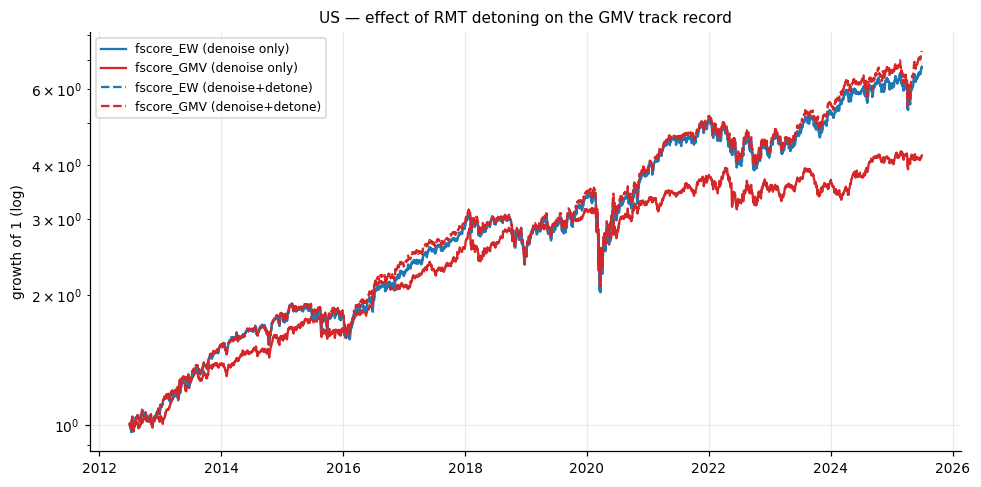

In [10]:
fig, ax = plt.subplots(figsize=(9, 4.5))
for label, st, ls in [("denoise only", study, "-"), ("denoise+detone", study_dt, "--")]:
    for strat, c in [("fscore_EW", "tab:blue"), ("fscore_GMV", "tab:red")]:
        nav_ = (1 + st.daily[strat].fillna(0)).cumprod()
        ax.plot(nav_.index, nav_, ls, color=c, lw=1.5, label=f"{strat} ({label})")
ax.set_yscale("log"); ax.set_ylabel("growth of 1 (log)")
ax.set_title(f"{MARKET.upper()} — effect of RMT detoning on the GMV track record")
ax.legend(fontsize=8); plt.tight_layout()
save_fig("us_detone_comparison", directory=RESULTS_FIG)
plt.show()

### 5. Turnover and implied trading cost

One-way turnover per rebalance, computed on each strategy's actual weights
(so GMV pays for weight drift, not just for name changes); cost drag =
2 x turnover x 20 bp per side, already applied in the `net_*` columns above.
For reference, the random control is redrawn every year and turns over
roughly `1 - k/|universe|`, i.e. in the same range as the F-Score basket.

In [11]:
to = study.turnover_table()
to.loc["mean"] = to.mean()
cost = (2 * to.loc["mean"] * 0.0020).rename("annual cost drag")
pd.concat([to.round(3).T, cost.round(4)], axis=1)

,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,mean,annual cost drag
fscore_EW,0.667,0.533,0.600,0.533,0.467,0.500,0.500,0.633,0.533,0.567,0.600,0.667,0.567,0.0023
fscore_GMV,0.772,0.405,0.666,0.563,0.539,0.507,0.561,0.475,0.556,0.549,0.829,0.868,0.608,0.0024
fscore_GMVsec,0.701,0.543,0.629,0.572,0.386,0.503,0.683,0.696,0.791,0.738,0.814,0.848,0.659,0.0026
fscore_LS,1.333,1.200,1.200,1.100,0.933,1.133,1.333,1.383,1.085,1.187,1.200,1.400,1.207,0.0048
value_EW,0.200,0.267,0.200,0.333,0.300,0.267,0.433,0.300,0.167,0.167,0.367,0.267,0.272,0.0011
mktcap_EW,0.233,0.233,0.233,0.333,0.333,0.267,0.367,0.300,0.267,0.267,0.400,0.233,0.289,0.0012
liquidity_EW,0.667,0.667,0.600,0.533,0.467,0.633,0.833,0.700,0.533,0.633,0.600,0.733,0.633,0.0025


### 6. Does alpha survive the factor exposures?

Daily excess returns regressed on the Fama-French three factors (market,
size, value) with Newey-West standard errors. The `alpha_significant` column
is the verdict at the study's single level, 5%.

In [12]:
ff = fetch_ff_factors("us")
series = {s: study.daily[s].dropna()
          for s in ["fscore_EW", "fscore_GMV", "value_EW"]}
reg = pd.DataFrame({s: factor_regression(r, ff) for s, r in series.items()}).T
reg.round(4)

,alpha_daily,alpha_annual,alpha_tstat,alpha_pvalue,alpha_significant,alpha,beta_mkt,beta_smb,beta_hml,r2,n_obs
fscore_EW,0.000055,0.013774,0.762992,0.445468,False,0.05,1.081901,0.074746,0.20163,0.893581,3258
fscore_GMV,0.000038,0.009529,0.350897,0.725666,False,0.05,0.735999,-0.172821,0.097122,0.622322,3258
value_EW,0.000112,0.028144,1.332674,0.182639,False,0.05,1.114264,0.128832,0.311378,0.875111,3258


In [13]:
RESULTS = ROOT / "results"
RESULTS.mkdir(exist_ok=True)
tbl.to_csv(RESULTS / f"{MARKET}_summary.csv")
placements.to_csv(RESULTS / f"{MARKET}_mc_placement.csv")
to.to_csv(RESULTS / f"{MARKET}_turnover.csv")
reg.to_csv(RESULTS / f"{MARKET}_factor_regression.csv")
diag.to_csv(RESULTS / f"{MARKET}_diagnostics.csv", index=False)
print("saved to", RESULTS)

saved to C:\Users\miked\OneDrive\Desktop\Career\WQU\Cap Project\fscore_capstone\results


### 7. Reading the results

*(filled in after execution)*